In [ ]:
import pandas as pd
import glob
import os
from google.colab import drive

# 1. Force refresh Google Drive to ensure Colab sees the newest files
drive.mount('/content/drive', force_remount=True)

# 2. Path to Gold Layer
gold_path = "/content/drive/MyDrive/Project DEPI/SmartGrid_Gold_Data"

# 3. Get a list of ONLY the actual Parquet files (ignoring the _spark_metadata folder)
parquet_files = glob.glob(os.path.join(gold_path, "*.parquet"))
print(f"Found {len(parquet_files)} physical Parquet files in the folder.")

# 4. Read and concatenate all files manually
try:
    df_list = [pd.read_parquet(file) for file in parquet_files]
    df = pd.concat(df_list, ignore_index=True)

    # Apply your previous processing
    df['timestamp'] = pd.to_datetime(df['window'].apply(lambda x: x['start']))
    df = df[['timestamp', 'meter_id', 'avg_active_power', 'avg_voltage']]
    df = df.sort_values(by=["meter_id", "timestamp"]).reset_index(drop=True)

    print(f"Data loaded successfully by bypassing metadata! True Number of rows: {len(df)}")
    display(df.head())
    display(df.tail()) # Show the end to see the newest dates

except Exception as e:
    print(f"Error processing files: {e}")

Mounted at /content/drive
Found 954 physical Parquet files in the folder.
Data loaded successfully by bypassing metadata! True Number of rows: 8638


,timestamp,meter_id,avg_active_power,avg_voltage
0,2024-01-01 00:00:00,house_1,0.310993,NaN
1,2024-01-01 00:05:00,house_1,0.306314,230.792800
2,2024-01-01 00:10:00,house_1,0.227596,229.073910
3,2024-01-01 00:15:00,house_1,0.386768,228.856475
4,2024-01-01 00:20:00,house_1,0.322162,230.062660


,timestamp,meter_id,avg_active_power,avg_voltage
8633,2024-01-30 23:25:00,house_1,0.436558,230.443307
8634,2024-01-30 23:30:00,house_1,0.220642,230.515615
8635,2024-01-30 23:35:00,house_1,NaN,229.068541
8636,2024-01-30 23:40:00,house_1,0.342417,NaN
8637,2024-01-30 23:45:00,house_1,0.397083,229.585431


# Environment Setup & Library Imports

In [ ]:
# Cell 1: Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

# Ignore warning messages for cleaner output
warnings.filterwarnings('ignore')

# Set aesthetic parameters for seaborn plots
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully. Environment is ready.")

Libraries imported successfully. Environment is ready.


# Show sample data

# Data Loading & Advanced Preprocessing

In [ ]:
# Cell 2: Data Loading and Preprocessing
import pandas as pd

gold_path = "/content/drive/MyDrive/Project DEPI/SmartGrid_Gold_Data"

try:
    # Load all parquet files from the directory
    df = pd.read_parquet(gold_path)
    print(f"Initial data loaded. Rows: {len(df)}")

    # Extract timestamp from the window struct
    df['timestamp'] = pd.to_datetime(df['window'].apply(lambda x: x['start']))

    # Sort data chronologically per meter
    df = df.sort_values(by=["meter_id", "timestamp"]).reset_index(drop=True)

    # Advanced NaNs Handling: Using 'transform' instead of 'apply' to fix the index error
    df['avg_active_power'] = df.groupby('meter_id')['avg_active_power'].transform(lambda x: x.interpolate(method='linear'))
    df['avg_voltage'] = df.groupby('meter_id')['avg_voltage'].transform(lambda x: x.interpolate(method='linear'))

    # Drop rows that still have NaNs (usually at the very beginning of the series)
    df = df.dropna()

    # Keep only necessary columns
    df = df[['timestamp', 'meter_id', 'avg_active_power', 'avg_voltage']]

    print(f"Data cleaned and preprocessed. Final Rows: {len(df)}")
    display(df.head())

except Exception as e:
    print(f"Error loading data: {e}. Please check the path and ensure Parquet files exist.")

Initial data loaded. Rows: 8638
Data cleaned and preprocessed. Final Rows: 8637


,timestamp,meter_id,avg_active_power,avg_voltage
1,2024-01-01 00:05:00,house_1,0.306314,230.792800
2,2024-01-01 00:10:00,house_1,0.227596,229.073910
3,2024-01-01 00:15:00,house_1,0.386768,228.856475
4,2024-01-01 00:20:00,house_1,0.322162,230.062660
5,2024-01-01 00:25:00,house_1,0.218040,231.719367


# Exploratory Data Analysis (EDA) - Distributions

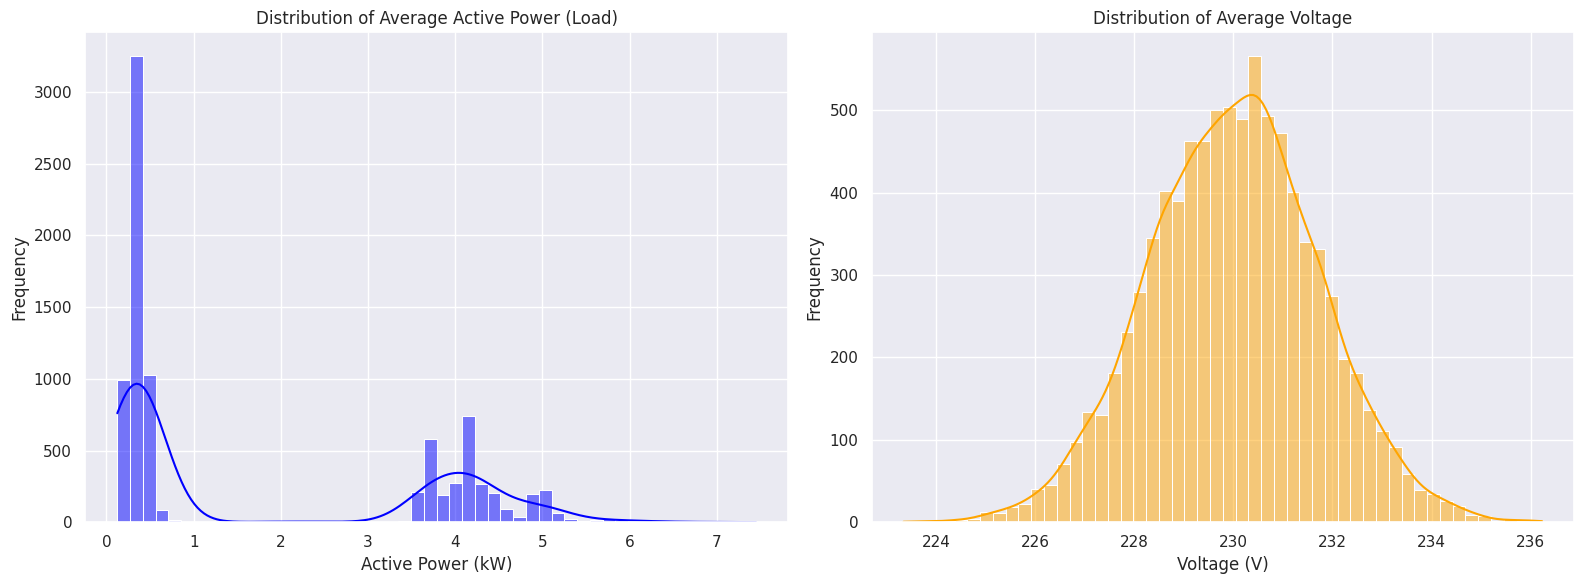

In [ ]:
# Cell 3: EDA - Statistical Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Active Power Distribution
sns.histplot(df['avg_active_power'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Average Active Power (Load)')
axes[0].set_xlabel('Active Power (kW)')
axes[0].set_ylabel('Frequency')

# Voltage Distribution
sns.histplot(df['avg_voltage'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Average Voltage')
axes[1].set_xlabel('Voltage (V)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA) - Time Series Trends

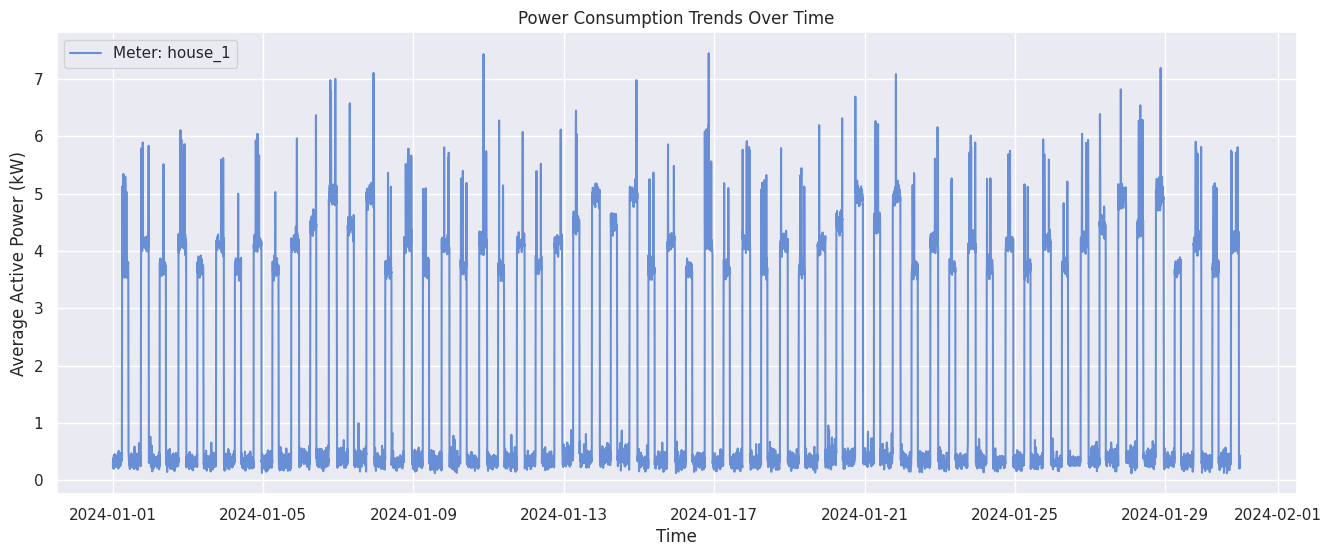

In [ ]:
# Cell 4: EDA - Time Series Plot
plt.figure(figsize=(16, 6))

# Plot power consumption over time for a sample of meters (up to 3)
sample_meters = df['meter_id'].unique()[:3]

for meter in sample_meters:
    meter_data = df[df['meter_id'] == meter]
    plt.plot(meter_data['timestamp'], meter_data['avg_active_power'], label=f'Meter: {meter}', alpha=0.8)

plt.title('Power Consumption Trends Over Time')
plt.xlabel('Time')
plt.ylabel('Average Active Power (kW)')
plt.legend()
plt.show()

# Advanced Feature Engineering (The Secret to High Accuracy)

In [ ]:
# Cell 5: Feature Engineering
df_features = df.copy()

# 1. Temporal Features: Extracting meaningful time components
df_features['hour'] = df_features['timestamp'].dt.hour
df_features['minute'] = df_features['timestamp'].dt.minute
df_features['dayofweek'] = df_features['timestamp'].dt.dayofweek
df_features['is_weekend'] = df_features['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Lag Features: What was the consumption 1 and 2 steps ago?
df_features['lag_1_power'] = df_features.groupby('meter_id')['avg_active_power'].shift(1)
df_features['lag_2_power'] = df_features.groupby('meter_id')['avg_active_power'].shift(2)

# 3. Rolling Features: Moving average of the last 3 steps
df_features['rolling_mean_3'] = df_features.groupby('meter_id')['avg_active_power'].transform(lambda x: x.rolling(window=3).mean())

# Drop NaN values generated by shifting operations
df_features = df_features.dropna().reset_index(drop=True)

# Encode categorical meter_id to numeric values for XGBoost
le = LabelEncoder()
df_features['meter_encoded'] = le.fit_transform(df_features['meter_id'])

print("Feature Engineering completed successfully.")
display(df_features.head())

Feature Engineering completed successfully.


,timestamp,meter_id,avg_active_power,avg_voltage,hour,minute,dayofweek,is_weekend,lag_1_power,lag_2_power,rolling_mean_3,meter_encoded
0,2024-01-01 00:15:00,house_1,0.386768,228.856475,0,15,0,0,0.227596,0.306314,0.306892,0
1,2024-01-01 00:20:00,house_1,0.322162,230.062660,0,20,0,0,0.386768,0.227596,0.312175,0
2,2024-01-01 00:25:00,house_1,0.218040,231.719367,0,25,0,0,0.322162,0.386768,0.308990,0
3,2024-01-01 00:30:00,house_1,0.269664,233.636009,0,30,0,0,0.218040,0.322162,0.269955,0
4,2024-01-01 00:35:00,house_1,0.321288,230.559440,0,35,0,0,0.269664,0.218040,0.269664,0


# Time-Series Data Splitting

In [ ]:
# Cell 6: Data Splitting (Chronological)
# Target variable is what we want to predict
target = 'avg_active_power'

# Features to feed into the model
features = [
    'meter_encoded', 'avg_voltage', 'hour', 'minute',
    'dayofweek', 'is_weekend', 'lag_1_power', 'lag_2_power', 'rolling_mean_3'
]

X = df_features[features]
y = df_features[target]

# VERY IMPORTANT: shuffle=False to prevent data leakage in time-series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 6908 rows
Testing set size: 1727 rows


# **Model Training (XGBoost Regressor)**

In [ ]:
# Cell 7: Model Training
print("Initializing XGBoost Regressor...")

# Configure the model with robust hyperparameters
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# Train the model
print("Training the model... (This might take a moment)")
xgb_model.fit(X_train, y_train)
print("Model training completed successfully!")

Initializing XGBoost Regressor...
Training the model... (This might take a moment)
Model training completed successfully!


# Model Evaluation & Performance Metrics

In [ ]:
# Cell 8: Model Evaluation
# Make predictions on the unseen test set
y_pred = xgb_model.predict(X_test)

# Calculate Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")
print("---------------------------------")
print("An R2 score closer to 1.0 indicates a highly accurate model.")

--- Model Performance Metrics ---
Root Mean Squared Error (RMSE): 0.1136
Mean Absolute Error (MAE): 0.0452
R-squared Score (R2): 0.9966
---------------------------------
An R2 score closer to 1.0 indicates a highly accurate model.


# Visualizing Results (Feature Importance & Predictions)

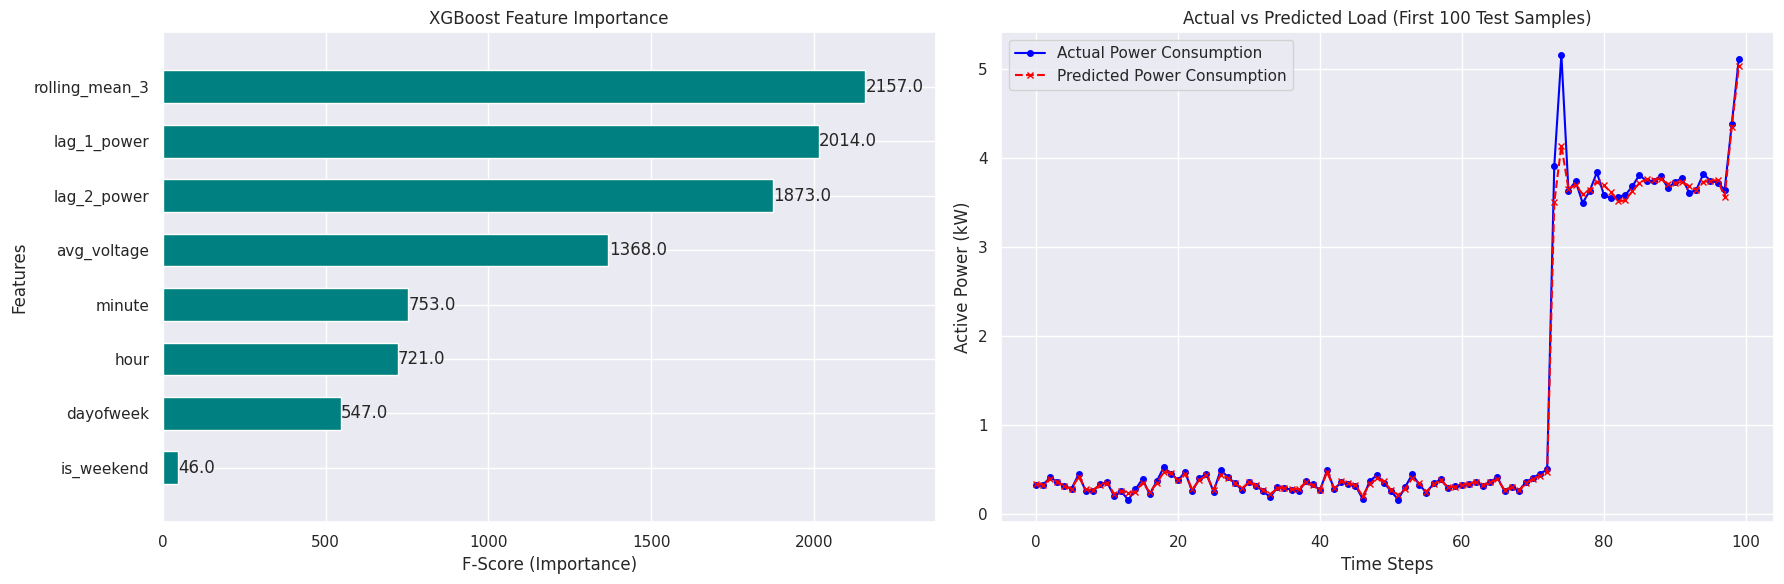

In [ ]:
# Cell 9: Results Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Feature Importance Plot
xgb.plot_importance(xgb_model, ax=axes[0], height=0.6, color='teal')
axes[0].set_title('XGBoost Feature Importance')
axes[0].set_xlabel('F-Score (Importance)')

# 2. Actual vs Predicted Plot (For the first 100 test samples to keep it clear)
samples_to_plot = 100
axes[1].plot(y_test.values[:samples_to_plot], label='Actual Power Consumption', color='blue', marker='o', markersize=4)
axes[1].plot(y_pred[:samples_to_plot], label='Predicted Power Consumption', color='red', linestyle='--', marker='x', markersize=4)
axes[1].set_title(f'Actual vs Predicted Load (First {samples_to_plot} Test Samples)')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Active Power (kW)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Exporting ML_output for Power BI Dashboard

In [ ]:
# Cell 10: Exporting Final Data for Power BI Dashboard
import pandas as pd

print("Preparing final dataset for Power BI...")

# 1. Extract the test dataset to retrieve the correct timestamps
# Since shuffle=False was used, the indices remain aligned
results_df = df_features.loc[X_test.index].copy()

# 2. Add the model's predictions alongside the actual power consumption
results_df['Actual_Power'] = y_test.values
results_df['Predicted_Power'] = y_pred

# 3. Clean the dataset and keep only the columns required for the Power BI dashboard
dashboard_df = results_df[['timestamp', 'meter_id', 'avg_voltage', 'Actual_Power', 'Predicted_Power']]

# 4. Define the final export path inside the Google Drive project folder

csv_export_path = "/content/drive/MyDrive/Project DEPI/ML_output.csv"

# 5. Save the dataset as a CSV file (excluding the numeric index for a cleaner output)
dashboard_df.to_csv(csv_export_path, index=False)

print(f"Success! Dashboard data has been saved as a CSV file at: {csv_export_path}")
print(f"Total rows exported for Power BI: {len(dashboard_df)}")

Preparing final dataset for Power BI...
Success! Dashboard data has been saved as a CSV file at: /content/drive/MyDrive/Project DEPI/ML_output.csv
Total rows exported for Power BI: 1727


# Exporting Golden_layer_output Power BI

In [ ]:
# Cell 11: Exporting ALL Historical Gold Data into ONE Clean CSV for Power BI
import pandas as pd
import glob
import os

print("Starting to compile all historical Gold Layer files...")

# 1. Path to your Gold Layer folder in Google Drive
gold_folder_path = "/content/drive/MyDrive/Project DEPI/SmartGrid_Gold_Data"

try:
    # 2. Get a list of all actual Parquet files in the folder
    all_parquet_files = glob.glob(os.path.join(gold_folder_path, "*.parquet"))

    if not all_parquet_files:
        print("No Parquet files found. Please check your path or ensure Spark has written data.")
    else:
        print(f"Found {len(all_parquet_files)} Parquet files. Merging them now...")

        # 3. Read and concatenate all parquet files into a single Pandas DataFrame
        historical_df_list = [pd.read_parquet(file) for file in all_parquet_files]
        combined_historical_df = pd.concat(historical_df_list, ignore_index=True)

        # 4. Clean the timestamp column just like we did before
        combined_historical_df['timestamp'] = pd.to_datetime(combined_historical_df['window'].apply(lambda x: x['start']))

        # 5. Rearrange and select clean columns for the dashboard creator
        clean_historical_df = combined_historical_df[['timestamp', 'meter_id', 'avg_active_power', 'avg_voltage']]

        # 6. Sort by meter and time to make the charts smooth
        clean_historical_df = clean_historical_df.sort_values(by=["meter_id", "timestamp"]).reset_index(drop=True)


        historical_csv_path = "/content/drive/MyDrive/Project DEPI/Golden_layer_output.csv"

        # 8. Save as a single clean CSV file
        clean_historical_df.to_csv(historical_csv_path, index=False)

        print(f"\n[DONE] Successfully compiled all historical data!")
        print(f"Saved at: {historical_csv_path}")
        print(f"Total historical rows exported: {len(clean_historical_df)}")

        # Display a quick preview to make sure it looks perfect
        display(clean_historical_df.head())

except Exception as e:
    print(f"An error occurred while compiling historical data: {e}")

Starting to compile all historical Gold Layer files...
Found 954 Parquet files. Merging them now...

[DONE] Successfully compiled all historical data!
Saved at: /content/drive/MyDrive/Project DEPI/Historical_Grid_Data.csv
Total historical rows exported: 8638


,timestamp,meter_id,avg_active_power,avg_voltage
0,2024-01-01 00:00:00,house_1,0.310993,NaN
1,2024-01-01 00:05:00,house_1,0.306314,230.792800
2,2024-01-01 00:10:00,house_1,0.227596,229.073910
3,2024-01-01 00:15:00,house_1,0.386768,228.856475
4,2024-01-01 00:20:00,house_1,0.322162,230.062660


In [ ]:
# Cell 12: Exporting the Trained XGBoost Model
import joblib
import os

print("Exporting the trained model...")

# Save path in Google Drive
model_path = "/content/drive/MyDrive/Project DEPI/xgboost_smartgrid_model.pkl"

# Save the trained model using the joblib library
joblib.dump(xgb_model, model_path)

print(f"Model successfully saved at: {model_path}")

Exporting the trained model...
Model successfully saved at: /content/drive/MyDrive/Project DEPI/xgboost_smartgrid_model.pkl
